![alt text](./Cerny_logo_1.jpg)

# Analysis of Cerny ventilation recordings

## Processing and analysis of HFOV cases `AT000001-AT001251`

This Notebook produces Excel statistics about ventilator parameters in cases ventilated with HFOV. It also exports barplots showing statistics on ventilation modes used. It does not produse graphs on individual recordings . 

### 1. Import the necessary libraries and setting options

In [1]:
import IPython
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as dates

import os
import sys
import pickle

from pandas import Series, DataFrame
from datetime import datetime, timedelta
from scipy import stats

%matplotlib inline
matplotlib.style.use('classic')
matplotlib.rcParams['figure.facecolor'] = 'w'

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 300)
pd.set_option('mode.chained_assignment', None) 

In [2]:
print("Python version: {}".format(sys.version))
print("pandas version: {}".format(pd.__version__))
print("matplotlib version: {}".format(matplotlib.__version__))
print("NumPy version: {}".format(np.__version__))
print("IPython version: {}".format(IPython.__version__))

Python version: 3.11.7 (main, Dec 15 2023, 12:09:04) [Clang 14.0.6 ]
pandas version: 2.1.4
matplotlib version: 3.8.0
NumPy version: 1.26.3
IPython version: 8.20.0


In [3]:
# Define styling of boxplots
medianprops = {'color':'black', 'linewidth':2}; boxprops = {'color':'black', 'linestyle':'-'}
whiskerprops = {'color':'black', 'linestyle':'-'}; capprops = {'color':'black', 'linestyle':'-'}
flierprops = {'color':'black', 'marker': '.'}
meanprops =  {'marker':'D', 'markeredgecolor':'black', 'markerfacecolor':'black'}

### 2. List and set the working directory and the directory to write out data

In [4]:
# Topic of the Notebook which will also be the name of the subfolder containing results
TOPIC = 'HFOV'

# Path to project folder containing clinical data (current weights only) and for export of results
PATH = os.path.join(os.sep, 'Users', 'guszti', 'Library', 'Mobile Documents', 'com~apple~CloudDocs', 
                            'Documents', 'Research', 'Ventilation')

# Name of the external hard drive
DRIVE = 'GUSZTI'

# Folder containing the file with the manually collected clinical data
DIR_READ_CLIN = os.path.join(os.sep, PATH, 'ventilation_fabian_new')

# Processed data loaded from external drive
DIR_READ = os.path.join(os.sep, 'Volumes', DRIVE, 'data_dump', 'fabian_new')

# Results will be written in this folder
DIR_WRITE =  os.path.join(os.sep, PATH, 'ventilation_fabian_new', 'Analyses', TOPIC)
os.makedirs(DIR_WRITE, exist_ok=True)

# Images and raw data will be written on an external hard drive
DATA_DUMP = os.path.join(os.sep, 'Volumes', DRIVE, 'data_dump', 'fabian_new', TOPIC)
os.makedirs(DATA_DUMP, exist_ok=True)

In [5]:
DIR_READ_CLIN, DIR_READ, DIR_WRITE, DATA_DUMP,

('/Users/guszti/Library/Mobile Documents/com~apple~CloudDocs/Documents/Research/Ventilation/ventilation_fabian_new',
 '/Volumes/GUSZTI/data_dump/fabian_new',
 '/Users/guszti/Library/Mobile Documents/com~apple~CloudDocs/Documents/Research/Ventilation/ventilation_fabian_new/Analyses/HFOV',
 '/Volumes/GUSZTI/data_dump/fabian_new/HFOV')

### 3. Import processed data

#### A. Processed ventilator data from pickle archives

This recordings all have >10 minutes of HFOV data

In [6]:
# All recordings included in the final analysis, both HFOV and conventional ventilation data
with open(os.path.join(DATA_DUMP, 'data_pars_hfov.pickle'), 'rb') as handle:
    data_pars_hfov = pickle.load(handle)

# All recordings included in the final analysis, only HFOV parts
with open(os.path.join(DATA_DUMP, 'data_pars_hfov_only.pickle'), 'rb') as handle:
    data_pars_hfov_only = pickle.load(handle)

# Only recordings selected as HFOV-VG and only HFOV-VG parts
with open(os.path.join(DATA_DUMP, 'data_pars_hfov_vg_only.pickle'), 'rb') as handle:
    data_pars_hfov_vg_only = pickle.load(handle)

# Only recordings selected as HFOV-noVG and only HFOV-noVG parts
with open(os.path.join(DATA_DUMP, 'data_pars_hfov_novg_only.pickle'), 'rb') as handle:
    data_pars_hfov_novg_only = pickle.load(handle)

In [7]:
len(data_pars_hfov), len(data_pars_hfov_only), len(data_pars_hfov_vg_only), len(data_pars_hfov_novg_only),

(51, 51, 26, 22)

#### B. Blood gases

In [8]:
with open(os.path.join(DIR_READ, 'blood_gases_new.pickle'), 'rb') as handle:
    blood_gases_automatic = pickle.load(handle)
blood_gases_hfov = {key:value for key,value in blood_gases_automatic.items() if key in data_pars_hfov.keys()}
len(blood_gases_hfov)

50

#### C. Manually collected and curated clinical data

In [9]:
clin_data_hfov = pd.read_excel(os.path.join(DIR_READ_CLIN, 'clinical_data_hfov_210124.xlsx'),
                 sheet_name='hfov_cases', header=0, index_col=[0,1])
clin_data_hfov.reset_index(1, drop=True, inplace=True)
len(clin_data_hfov)

64

In [10]:
# Limit clinical data for the final dataset
clin_data_hfov = clin_data_hfov.loc[data_pars_hfov.keys()]
len(clin_data_hfov)

51

### 4. Cleanup clinical data

In [11]:
column_names_orig = clin_data_hfov.columns
column_names_orig

Index(['Date of Birth', 'Gestational Age (weeks)', 'Birth Weight (grams)',
       'Postnatal Age ', 'Corrected gestational Age (weeks)', 'Weight (grams)',
       'ICD', 'Pathology_English', 'Recording start', 'Recording end',
       'Duration (days)',
       'Primary diagnosis (1-congenital malformation, 2-MAS, 3-hydrops, 4-asphyxia, 5-PPHN, 6-Infection, 7-Emphysema/atelectasis, 8-RDS, 9-Other/Uncertain)',
       'Congenital malformation (0-None, 1-hernia diaphragm, 2-omphalocele, 3-anus atresia, 4-multiplex malformation, 5-CCAM, 6-hypoplasia pulm, 7-urogenital malform)',
       'Reason for transfer (1-surgery, 2-further examination, 3-hypothermia)',
       'Reason for HFO (1-PPHN, 2-PTX, 3-lung failure, 4-respiratory failure, 5-not available)',
       'Start of ventillation', 'Start of HFO', 'End of HFO', 'End of vent',
       'Opioids (0-no, 1-fentanyl, 2-morphine)', 'Midazolam (0-no, 1-yes)',
       '(Muscle relaxant 0-none, 1-thiopenthal, 2-tracrium, 3-atracurium)',
       'iNO (0-

In [12]:
column_names_new = ['Date of Birth', 'Gestational Age (weeks)', 'Birth Weight (grams)',
                    'Postnatal Age ', 'Corrected gestational Age (weeks)', 'Weight (grams)',
                    'ICD', 'Pathology_English', 'Recording start', 'Recording end',
                    'Duration (days)', 'Primary diagnosis', 'Congenital malformation',
                    'Reason for transfer', 'Reason for HFO', 'Start of ventilation', 'Start of HFO', 'End of HFO', 'End of vent',
                    'Opioids', 'Midazolam', 'Muscle relaxant', 'iNO', 'Dopamine', 'Dobutamine', 'Noradrenaline', 'Milrinone', 'Adrenaline',
                    'Curosurf', 'Size of ETT', 'Other', 'Exclude', 'Reason to consider/exclude']

rename_dct = dict(zip(column_names_orig, column_names_new))
rename_dct

{'Date of Birth': 'Date of Birth',
 'Gestational Age (weeks)': 'Gestational Age (weeks)',
 'Birth Weight (grams)': 'Birth Weight (grams)',
 'Postnatal Age ': 'Postnatal Age ',
 'Corrected gestational Age (weeks)': 'Corrected gestational Age (weeks)',
 'Weight (grams)': 'Weight (grams)',
 'ICD': 'ICD',
 'Pathology_English': 'Pathology_English',
 'Recording start': 'Recording start',
 'Recording end': 'Recording end',
 'Duration (days)': 'Duration (days)',
 'Primary diagnosis (1-congenital malformation, 2-MAS, 3-hydrops, 4-asphyxia, 5-PPHN, 6-Infection, 7-Emphysema/atelectasis, 8-RDS, 9-Other/Uncertain)': 'Primary diagnosis',
 'Congenital malformation (0-None, 1-hernia diaphragm, 2-omphalocele, 3-anus atresia, 4-multiplex malformation, 5-CCAM, 6-hypoplasia pulm, 7-urogenital malform)': 'Congenital malformation',
 'Reason for transfer (1-surgery, 2-further examination, 3-hypothermia)': 'Reason for transfer',
 'Reason for HFO (1-PPHN, 2-PTX, 3-lung failure, 4-respiratory failure, 5-not ava

In [13]:
# Rename columns with simpler names
clin_data_hfov.rename(rename_dct, axis=1, inplace=True)
clin_data_hfov.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51 entries, AT000033 to AT001248
Data columns (total 33 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Date of Birth                      51 non-null     datetime64[ns]
 1   Gestational Age (weeks)            51 non-null     int64         
 2   Birth Weight (grams)               51 non-null     int64         
 3   Postnatal Age                      51 non-null     float64       
 4   Corrected gestational Age (weeks)  51 non-null     float64       
 5   Weight (grams)                     51 non-null     int64         
 6   ICD                                51 non-null     object        
 7   Pathology_English                  51 non-null     object        
 8   Recording start                    51 non-null     datetime64[ns]
 9   Recording end                      51 non-null     datetime64[ns]
 10  Duration (days)                 

In [14]:
# All recordings included in the study
recordings_included_all = sorted(data_pars_hfov.keys())
print(f'All recordings included: {len(recordings_included_all)}')

All recordings included: 51


In [15]:
# Which recordings were exclusively HFOV
recordings_exclusively_hfov = []
recordings_hfov_plus_other = []

for case in data_pars_hfov:
    if all(data_pars_hfov[case]['Ventilator_mode'] == 'HFO'):
        recordings_exclusively_hfov.append(case)
    else :
        recordings_hfov_plus_other.append(case)

print(f'Only HFOV: {len(recordings_exclusively_hfov)}','\n',f'HFOV and other mode: {len(recordings_hfov_plus_other)}')

Only HFOV: 38 
 HFOV and other mode: 13


In [16]:
recordings_hfov_vg_only = sorted(data_pars_hfov_vg_only.keys())
recordings_hfov_novg_only = sorted(data_pars_hfov_novg_only.keys())
print(f'HFOV-VG: {len(recordings_hfov_vg_only)}','\n',f'HFOV without VG: {len(recordings_hfov_novg_only)}')

HFOV-VG: 26 
 HFOV without VG: 22


### 5. Statistics on clinical details of the selected cases

In [17]:
clin_data_hfov.head(2)

,Date of Birth,Gestational Age (weeks),Birth Weight (grams),Postnatal Age,Corrected gestational Age (weeks),Weight (grams),ICD,Pathology_English,Recording start,Recording end,Duration (days),Primary diagnosis,Congenital malformation,Reason for transfer,Reason for HFO,Start of ventilation,Start of HFO,End of HFO,End of vent,Opioids,Midazolam,Muscle relaxant,iNO,Dopamine,Dobutamine,Noradrenaline,Milrinone,Adrenaline,Curosurf,Size of ETT,Other,Exclude,Reason to consider/exclude
AT000033,2020-11-20 06:57:00,36,1500,0.131377,36.0,1500,"['P073', 'Q336', 'I270', '_0000', 'P015', 'Q79...","['Preterm newborn, unspecified weeks of gestat...",2020-11-20 09:13:11,2020-11-20 10:06:11,0.036806,1,1.0,1.0,1.0,08:55:00,08:55:00,09:50:00,09:50:00,2.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0,NaN
AT000034,2020-11-20 08:31:00,35,2000,0.128681,35.0,2000,"['Q792', 'P073', 'P293', '_0000']","['Exomphalos', 'Preterm newborn, unspecified w...",2020-11-20 10:49:48,2020-11-20 11:36:18,0.032292,1,2.0,1.0,1.0,10:34:00,10:34:00,11:30:00,11:30:00,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,3.0,NaN,0,NaN


In [18]:
clin_data_hfov_vg = clin_data_hfov.loc[recordings_hfov_vg_only]
clin_data_hfov_novg = clin_data_hfov.loc[recordings_hfov_novg_only]

#### A. Demographic details

In [19]:
to_include = ['Gestational Age (weeks)', 'Birth Weight (grams)', 'Postnatal Age ', 'Corrected gestational Age (weeks)',
                       'Weight (grams)', 'Duration (days)', ]

In [20]:
percentiles = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]

clin_data_hfov_stats = round(clin_data_hfov[to_include].describe(percentiles=percentiles), 2)
clin_data_hfov_vg_stats = round(clin_data_hfov_vg[to_include].describe(percentiles=percentiles), 2)
clin_data_hfov_novg_stats = round(clin_data_hfov_novg[to_include].describe(percentiles=percentiles), 2)

In [21]:
clin_data_hfov_stats

,Gestational Age (weeks),Birth Weight (grams),Postnatal Age,Corrected gestational Age (weeks),Weight (grams),Duration (days)
count,51.00,51.00,51.00,51.00,51.00,51.00
mean,35.24,2596.76,3.93,35.78,2639.31,0.06
std,5.25,1117.90,13.29,4.67,1074.88,0.03
min,23.00,460.00,0.08,23.00,490.00,0.01
1%,23.50,475.00,0.08,23.50,520.00,0.02
5%,24.00,590.00,0.09,25.75,642.50,0.02
25%,32.00,1810.00,0.13,33.55,1925.00,0.03
50%,38.00,3000.00,0.19,38.00,3000.00,0.05
75%,39.00,3500.00,0.92,39.10,3500.00,0.07
95%,40.00,3945.00,14.87,40.40,3945.00,0.12


In [22]:
clin_data_hfov_vg_stats

,Gestational Age (weeks),Birth Weight (grams),Postnatal Age,Corrected gestational Age (weeks),Weight (grams),Duration (days)
count,26.00,26.00,26.00,26.00,26.00,26.00
mean,35.50,2760.96,3.15,35.93,2796.35,0.06
std,5.49,1062.74,12.44,4.95,1031.58,0.03
min,24.00,630.00,0.08,24.00,665.00,0.02
1%,24.00,638.75,0.08,24.00,673.75,0.02
5%,24.00,673.75,0.09,25.00,812.50,0.02
25%,32.75,2185.00,0.13,33.58,2185.00,0.04
50%,38.00,3135.00,0.19,38.00,3100.00,0.06
75%,40.00,3500.00,0.51,40.00,3507.50,0.07
95%,40.00,3830.00,6.42,40.08,3867.50,0.12


In [23]:
clin_data_hfov_novg_stats

,Gestational Age (weeks),Birth Weight (grams),Postnatal Age,Corrected gestational Age (weeks),Weight (grams),Duration (days)
count,22.00,22.00,22.00,22.00,22.00,22.00
mean,34.82,2438.18,5.32,35.56,2495.00,0.05
std,5.41,1249.15,15.22,4.76,1190.55,0.03
min,23.00,460.00,0.10,23.00,490.00,0.01
1%,23.63,466.30,0.10,23.94,502.60,0.02
5%,26.00,493.00,0.11,27.62,553.50,0.02
25%,31.25,1560.00,0.15,32.58,1790.00,0.03
50%,37.50,2735.00,0.29,37.50,2735.00,0.04
75%,39.00,3402.50,1.45,39.00,3402.50,0.06
95%,40.95,3992.50,19.10,40.97,3992.50,0.12


In [24]:
writer = pd.ExcelWriter(os.path.join(DIR_WRITE, 'clinical_data_hfov.xlsx'))
clin_data_hfov.to_excel(writer, 'hfov_cases')
clin_data_hfov_stats.to_excel(writer, 'hfov_all_stats')
clin_data_hfov_vg_stats.to_excel(writer, 'hfov_vg_all_stats')
clin_data_hfov_novg_stats.to_excel(writer, 'hfov_novg_all_stats')
writer.close()

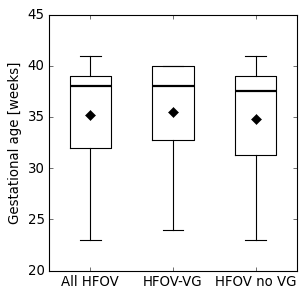

In [25]:
dpi = 200; filetype = 'jpg'

fig, ax = plt.subplots(figsize = (4,4))

ax.boxplot([clin_data_hfov['Gestational Age (weeks)'], clin_data_hfov_vg['Gestational Age (weeks)'],
            clin_data_hfov_novg['Gestational Age (weeks)']] ,
    widths = 0.5, whis = [0,100], showfliers = True, showmeans = True, meanprops=meanprops, medianprops=medianprops, 
    boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)

ax.tick_params(axis='both', which='major',)
ax.set_xticklabels(['All HFOV', 'HFOV-VG', 'HFOV no VG'],)
ax.set_ylabel('Gestational age [weeks]',)
ax.set_ylim(20, 45)
ax.grid(False)

fig.savefig(os.path.join(DIR_WRITE, f'gest_age_hfov.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1,);

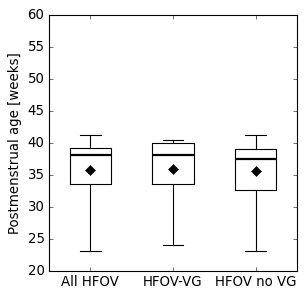

In [26]:
dpi = 200; filetype = 'jpg'

fig, ax = plt.subplots(figsize = (4,4))

ax.boxplot([clin_data_hfov['Corrected gestational Age (weeks)'], clin_data_hfov_vg['Corrected gestational Age (weeks)'],
            clin_data_hfov_novg['Corrected gestational Age (weeks)']] ,
    widths = 0.5, whis = [0,100], showfliers = True, showmeans = True, meanprops=meanprops, medianprops=medianprops, 
    boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)

ax.tick_params(axis='both', which='major',)
ax.set_xticklabels(['All HFOV', 'HFOV-VG', 'HFOV no VG'],)
ax.set_ylabel('Postmenstrual age [weeks]',)
ax.set_ylim(20, 60)
ax.grid(False)

fig.savefig(os.path.join(DIR_WRITE, f'corrected_gest_age_hfov.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1,);

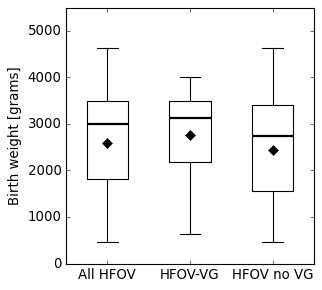

In [27]:
dpi = 200; filetype = 'jpg'

fig, ax = plt.subplots(figsize = (4,4))

ax.boxplot([clin_data_hfov['Birth Weight (grams)'], clin_data_hfov_vg['Birth Weight (grams)'], 
            clin_data_hfov_novg['Birth Weight (grams)']] ,
    widths = 0.5, whis = [0,100], showfliers = True, showmeans = True, meanprops=meanprops, medianprops=medianprops, 
    boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)

ax.tick_params(axis='both', which='major',)
ax.set_xticklabels(['All HFOV', 'HFOV-VG', 'HFOV no VG'],)
ax.set_ylabel('Birth weight [grams]',)
ax.set_ylim(0, 5500)
ax.grid(False)

fig.savefig(os.path.join(DIR_WRITE, f'Birth_weight_hfov.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1,);

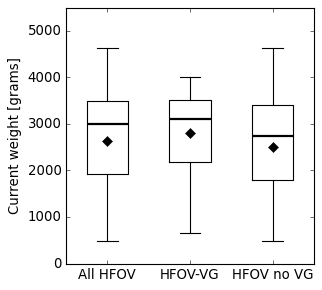

In [28]:
dpi = 200; filetype = 'jpg'

fig, ax = plt.subplots(figsize = (4,4))

ax.boxplot([clin_data_hfov['Weight (grams)'], clin_data_hfov_vg['Weight (grams)'], clin_data_hfov_novg['Weight (grams)']] ,
    widths = 0.5, whis = [0,100], showfliers = True, showmeans = True, meanprops=meanprops, medianprops=medianprops, 
    boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)

ax.tick_params(axis='both', which='major',)
ax.set_xticklabels(['All HFOV', 'HFOV-VG', 'HFOV no VG'],)
ax.set_ylabel('Current weight [grams]',)
ax.set_ylim(0, 5500)
ax.grid(False)

fig.savefig(os.path.join(DIR_WRITE, f'Current_weight_hfov.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1,);

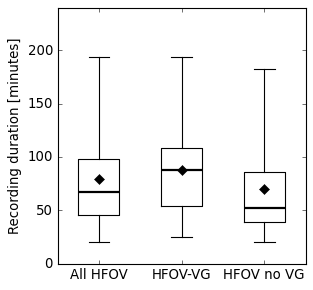

In [29]:
dpi = 200; filetype = 'jpg'

fig, ax = plt.subplots(figsize = (4,4))

ax.boxplot([clin_data_hfov['Duration (days)'] * 24 * 60, clin_data_hfov_vg['Duration (days)'] * 24 * 60, 
            clin_data_hfov_novg['Duration (days)'] * 24 * 60],
    widths = 0.5, whis = [0,100], showfliers = True, showmeans = True, meanprops=meanprops, medianprops=medianprops, 
    boxprops=boxprops, whiskerprops=whiskerprops, capprops=capprops, flierprops = flierprops)

ax.tick_params(axis='both', which='major',)
ax.set_xticklabels(['All HFOV', 'HFOV-VG', 'HFOV no VG'],)
ax.set_ylabel('Recording duration [minutes]',)
ax.set_ylim(0, 240)
ax.grid(False)

fig.savefig(os.path.join(DIR_WRITE, f'Recording_duration_hfov.{filetype}'), dpi = dpi, format = filetype, bbox_inches='tight', pad_inches=0.1,);

In [30]:
(clin_data_hfov[['Duration (days)']] * 24 * 60).describe()

,Duration (days)
count,51.000000
mean,79.256536
std,44.225237
min,19.800000
25%,45.441667
50%,67.033333
75%,98.425000
max,193.266667


In [31]:
(clin_data_hfov_vg[['Duration (days)']] * 24 * 60).describe()

,Duration (days)
count,26.000000
mean,87.921795
std,45.251990
min,25.116667
25%,53.700000
50%,87.625000
75%,107.887500
max,193.266667


In [32]:
(clin_data_hfov_novg[['Duration (days)']] * 24 * 60).describe()

,Duration (days)
count,22.000000
mean,69.748485
std,44.413749
min,19.800000
25%,39.333333
50%,51.891667
75%,85.816667
max,182.450000


In [33]:
clin_data_hfov_vg.columns

Index(['Date of Birth', 'Gestational Age (weeks)', 'Birth Weight (grams)',
       'Postnatal Age ', 'Corrected gestational Age (weeks)', 'Weight (grams)',
       'ICD', 'Pathology_English', 'Recording start', 'Recording end',
       'Duration (days)', 'Primary diagnosis', 'Congenital malformation',
       'Reason for transfer', 'Reason for HFO', 'Start of ventilation',
       'Start of HFO', 'End of HFO', 'End of vent', 'Opioids', 'Midazolam',
       'Muscle relaxant', 'iNO', 'Dopamine', 'Dobutamine', 'Noradrenaline',
       'Milrinone', 'Adrenaline', 'Curosurf', 'Size of ETT', 'Other',
       'Exclude', 'Reason to consider/exclude'],
      dtype='object')

In [34]:
for par in ['Gestational Age (weeks)', 'Birth Weight (grams)', 'Postnatal Age ', 'Corrected gestational Age (weeks)', 
            'Weight (grams)',]:
    print(par, ' ', stats.mannwhitneyu(clin_data_hfov_vg[par], clin_data_hfov_novg[par]), '\n',)

Gestational Age (weeks)   MannwhitneyuResult(statistic=312.0, pvalue=0.5944817721637962) 

Birth Weight (grams)   MannwhitneyuResult(statistic=338.0, pvalue=0.28649143499438934) 

Postnatal Age    MannwhitneyuResult(statistic=213.0, pvalue=0.13357744019327347) 

Corrected gestational Age (weeks)   MannwhitneyuResult(statistic=309.5, pvalue=0.6326126201556734) 

Weight (grams)   MannwhitneyuResult(statistic=339.5, pvalue=0.2726615948434836) 



#### B. Primary diagnosis 

(1-congenital malformation, 2-MAS, 3-hydrops, 4-asphyxia, 5-PPHN, 6-Infection, 7-Emphysema/atelectasis, 8-RDS, 9-Other/Uncertain)

congenital malformations: (0-None, 1-hernia diaphragm, 2-omphalocele, 3-anus atresia, 4-multiplex malformation, 5-CCAM, 6-hypoplasia pulm, 7-urogenital malform)

In [35]:
clin_data_hfov.groupby(['Primary diagnosis']).size()

Primary diagnosis
1      13
2      13
3       2
4       6
5       5
6       4
8       1
9       2
1,3     2
2,4     1
2,5     1
4,5     1
dtype: int64

In [36]:
clin_data_hfov.groupby(['Primary diagnosis', 'Congenital malformation']).size()

Primary diagnosis  Congenital malformation
1                  0.0                         1
                   1.0                         8
                   2.0                         1
                   3.0                         1
                   6.0                         1
                   7.0                         1
2                  0.0                        13
3                  0.0                         2
4                  0.0                         6
5                  0.0                         5
6                  0.0                         4
8                  0.0                         1
9                  0.0                         2
1,3                5.0                         1
                   6.0                         1
2,4                0.0                         1
2,5                6.0                         1
4,5                0.0                         1
dtype: int64

In [37]:
clin_data_hfov_vg.groupby(['Primary diagnosis']).size()

Primary diagnosis
1      5
2      9
3      2
4      4
5      1
6      2
8      1
9      1
2,4    1
dtype: int64

In [38]:
clin_data_hfov_vg.groupby(['Primary diagnosis', 'Congenital malformation']).size()

Primary diagnosis  Congenital malformation
1                  1.0                        3
                   2.0                        1
                   7.0                        1
2                  0.0                        9
3                  0.0                        2
4                  0.0                        4
5                  0.0                        1
6                  0.0                        2
8                  0.0                        1
9                  0.0                        1
2,4                0.0                        1
dtype: int64

In [39]:
clin_data_hfov_novg.groupby(['Primary diagnosis']).size()

Primary diagnosis
1      5
2      4
4      2
5      4
6      2
9      1
1,3    2
2,5    1
4,5    1
dtype: int64

In [40]:
clin_data_hfov_novg.groupby(['Primary diagnosis', 'Congenital malformation']).size()

Primary diagnosis  Congenital malformation
1                  0.0                        1
                   1.0                        4
2                  0.0                        4
4                  0.0                        2
5                  0.0                        4
6                  0.0                        2
9                  0.0                        1
1,3                5.0                        1
                   6.0                        1
2,5                6.0                        1
4,5                0.0                        1
dtype: int64

#### C. Reason for transfer 

(1-surgery, 2-further examination, 3-hypothermia)

In [41]:
clin_data_hfov['Reason for transfer'].value_counts()

Reason for transfer
2.0    28
1.0    14
3.0     8
Name: count, dtype: int64

In [42]:
clin_data_hfov_vg['Reason for transfer'].value_counts()

Reason for transfer
2.0    15
1.0     5
3.0     5
Name: count, dtype: int64

In [43]:
clin_data_hfov_novg['Reason for transfer'].value_counts()

Reason for transfer
2.0    12
1.0     7
3.0     3
Name: count, dtype: int64

#### D. Reason for HFO (1-PPHN, 2-PTX, 3-lung failure, 4-respiratory failure, 5-not available)

In [44]:
clin_data_hfov['Reason for HFO'].value_counts()

Reason for HFO
4.0    19
1.0    15
3.0    11
2.0     5
5.0     1
Name: count, dtype: int64

In [45]:
clin_data_hfov_vg['Reason for HFO'].value_counts()

Reason for HFO
4.0    13
1.0     7
3.0     4
5.0     1
2.0     1
Name: count, dtype: int64

In [46]:
clin_data_hfov_novg['Reason for HFO'].value_counts()

Reason for HFO
1.0    8
4.0    6
3.0    5
2.0    3
Name: count, dtype: int64

#### E. Sedation and muscle relaxant

Opioids (0-no, 1-fentanyl, 2-morphine)

Midazolam (0-no, 1-yes)
##### Thiopental is a sedative not a muscle relaxant
Muscle relaxant (0-none, 1-thiopenthal, 2-tracrium, 3-atracurium)


In [47]:
clin_data_hfov.groupby(['Opioids', 'Midazolam', 'Muscle relaxant']).size()

Opioids  Midazolam  Muscle relaxant
0.0      0.0        0.0                 6
                    1.0                 2
         1.0        0.0                 1
1.0      0.0        0.0                17
                    1.0                10
                    1.3                 1
         1.0        0.0                 4
                    3.0                 1
2.0      0.0        0.0                 6
                    2.0                 1
         1.0        0.0                 2
dtype: int64

In [48]:
clin_data_hfov_vg.groupby(['Opioids', 'Midazolam', 'Muscle relaxant']).size()

Opioids  Midazolam  Muscle relaxant
0.0      0.0        0.0                4
                    1.0                1
1.0      0.0        0.0                8
                    1.0                6
                    1.3                1
         1.0        0.0                1
2.0      0.0        0.0                4
                    2.0                1
dtype: int64

In [49]:
clin_data_hfov_novg.groupby(['Opioids', 'Midazolam', 'Muscle relaxant']).size()

Opioids  Midazolam  Muscle relaxant
0.0      0.0        0.0                2
                    1.0                1
         1.0        0.0                1
1.0      0.0        0.0                8
                    1.0                4
         1.0        0.0                1
                    3.0                1
2.0      0.0        0.0                2
         1.0        0.0                2
dtype: int64

#### F. Curosurf
Curosurf (0-no, 1-yes)

In [50]:
clin_data_hfov['Curosurf'].value_counts()

Curosurf
0.0    37
1.0    14
Name: count, dtype: int64

In [51]:
clin_data_hfov_vg['Curosurf'].value_counts()

Curosurf
0.0    21
1.0     5
Name: count, dtype: int64

In [52]:
clin_data_hfov_novg['Curosurf'].value_counts()

Curosurf
0.0    13
1.0     9
Name: count, dtype: int64

#### G. iNO

(0-no, 1-yes)

In [53]:
clin_data_hfov['iNO'].value_counts()

iNO
0.0    33
1.0    18
Name: count, dtype: int64

In [54]:
clin_data_hfov_vg['iNO'].value_counts()

iNO
0.0    18
1.0     8
Name: count, dtype: int64

In [55]:
clin_data_hfov_novg['iNO'].value_counts()

iNO
0.0    14
1.0     8
Name: count, dtype: int64

#### H. Inotropic support

Dopamine (0-no, 1-yes)
Dobutamine (0-no, 1-yes)
Adrenaline (0-no, 1-yes)
Noradrenaline (0-no, 1-yes)
Milrinone (0-no, 1-yes)

In [56]:
clin_data_hfov.groupby(['Dopamine', 'Dobutamine', 'Adrenaline', 'Noradrenaline', 'Milrinone']).size()

Dopamine  Dobutamine  Adrenaline  Noradrenaline  Milrinone
0.0       0.0         0.0         0.0            0.0          31
                                                 1.0           1
                                  1.0            1.0           3
                      1.0         0.0            0.0           1
                                  1.0            1.0           1
          1.0         0.0         0.0            0.0           3
                      1.0         0.0            0.0           1
1.0       0.0         0.0         0.0            0.0           4
                                                 1.0           2
                                  1.0            0.0           1
          1.0         0.0         0.0            0.0           3
dtype: int64

In [57]:
clin_data_hfov_vg.groupby(['Dopamine', 'Dobutamine', 'Adrenaline', 'Noradrenaline', 'Milrinone']).size()

Dopamine  Dobutamine  Adrenaline  Noradrenaline  Milrinone
0.0       0.0         0.0         0.0            0.0          15
                                  1.0            1.0           1
                      1.0         0.0            0.0           1
          1.0         0.0         0.0            0.0           2
                      1.0         0.0            0.0           1
1.0       0.0         0.0         0.0            0.0           3
                                                 1.0           1
                                  1.0            0.0           1
          1.0         0.0         0.0            0.0           1
dtype: int64

In [58]:
clin_data_hfov_vg.groupby(['Dopamine', 'Dobutamine', 'Adrenaline', 'Noradrenaline', 'Milrinone']).size()

Dopamine  Dobutamine  Adrenaline  Noradrenaline  Milrinone
0.0       0.0         0.0         0.0            0.0          15
                                  1.0            1.0           1
                      1.0         0.0            0.0           1
          1.0         0.0         0.0            0.0           2
                      1.0         0.0            0.0           1
1.0       0.0         0.0         0.0            0.0           3
                                                 1.0           1
                                  1.0            0.0           1
          1.0         0.0         0.0            0.0           1
dtype: int64

In [59]:
clin_data_hfov.loc['AT001229']

Date of Birth                                                      2023-06-16 00:00:00
Gestational Age (weeks)                                                             26
Birth Weight (grams)                                                               840
Postnatal Age                                                                70.298137
Corrected gestational Age (weeks)                                                 36.0
Weight (grams)                                                                    2000
ICD                                                   ['P072', 'P271', 'P249', 'P285']
Pathology_English                    ['Extreme immaturity of newborn, unspecified w...
Recording start                                                    2023-08-25 05:26:25
Recording end                                                      2023-08-25 07:09:19
Duration (days)                                                               0.071458
Primary diagnosis                          